In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy import stats

from func.configs import MAX_TIMELAG, WHISPER_SEG_LEN

plt.rcParams["font.family"] = "Arial"

mpl.rcParams["xtick.labelsize"] = 8
mpl.rcParams["ytick.labelsize"] = 8
mpl.rcParams["axes.labelsize"]  = 10
mpl.rcParams["axes.titlesize"] = 10
mpl.rcParams["legend.fontsize"] = 10

# Parameters
FEATURES = ["speech", "acoustics"]
LAGS = np.arange(0, int(MAX_TIMELAG * 1000), WHISPER_SEG_LEN)
LAGS_DISP = [0, 100, 200, 300, 400]

COLOR_MAP = {
    "speech":      "#9700F5",
    "acoustics":  "#4AD33B",
}

SUBS = [
    "sub-01", "sub-02", "sub-03", "sub-04", "sub-05",
    "sub-06", "sub-07", "sub-10", "sub-11", "sub-12"
]

In [2]:
# -------------------------
# Loading helpers
# -------------------------
def load_results(func_handle=np.max):

    df_char = {"lag": list(), "feature": list(), "sid": list(), "R": list()}
    for feature in FEATURES:
        for sub in SUBS:
            for lag in LAGS:
                r = func_handle(np.load(f"./results/LightGBM_iterate-lag_sub/char-level/{sub}/whisper-{feature}_timelg-{lag}_r-obs.npy"))
                df_char["lag"].append(lag)
                df_char["feature"].append(feature)
                df_char["sid"].append(sub)
                df_char["R"].append(r)
    df_char = pd.DataFrame(df_char)

    df_word = {"lag": list(), "feature": list(), "sid": list(), "R": list()}
    for feature in FEATURES:
        for sub in SUBS:
            for lag in LAGS:
                r = func_handle(np.load(f"./results/LightGBM_iterate-lag_sub/word-level/{sub}/whisper-{feature}_timelg-{lag}_r-obs.npy"))
                df_word["lag"].append(lag)
                df_word["feature"].append(feature)
                df_word["sid"].append(sub)
                df_word["R"].append(r)
    df_word = pd.DataFrame(df_word)

    return df_char, df_word


# -------------------------
# Stats helpers
# -------------------------
def get_mean_ci(vals, conf=0.95):

    mean = vals.mean()
    if len(vals) < 2:
        return mean, 0.0
    sem = stats.sem(vals)  # SE
    tcrit = stats.t.ppf((1 + conf) / 2, df=len(vals) - 1)
    ci = sem * tcrit

    return mean, ci


def check_normal(func_handle=np.max):
    
    for feature in FEATURES:
        for lag in LAGS:
            r_lag = list()
            for sub in SUBS:
                r = func_handle(np.load(f"./results/LightGBM_iterate-lag_sub/char-level/{sub}/whisper-{feature}_timelg-{lag}_r-obs.npy"))
                r_lag.append(r)
            r_lag = np.asarray(r_lag)
            shapiro_stat, shapiro_p = stats.shapiro(r_lag)
            results = "数据服从正态分布" if shapiro_p > 0.05 else "数据不服从正态分布"
            print(f"Char-Level, Feature: {feature}, Lag: {lag}ms, P_val: {shapiro_p:.3f}, Results: {results}")

    for feature in FEATURES:
        for lag in LAGS:
            r_lag = list()
            for sub in SUBS:
                r = func_handle(np.load(f"./results/LightGBM_iterate-lag_sub/word-level/{sub}/whisper-{feature}_timelg-{lag}_r-obs.npy"))
                r_lag.append(r)
            r_lag = np.asarray(r_lag)
            shapiro_stat, shapiro_p = stats.shapiro(r_lag)
            results = "数据服从正态分布" if shapiro_p > 0.05 else "数据不服从正态分布"
            print(f"Word-Level, Feature: {feature}, Lag: {lag}ms, P_val: {shapiro_p:.3f}, Results: {results}")


# -------------------------
# Plotting helpers
# -------------------------
def plot_line(ax, df, title=None, ylabel=False):

    for feature in FEATURES:
        dff = df[df["feature"] == feature].copy()
        c = COLOR_MAP[feature]

        means, lower, upper = list(), list(), list()
        vals_by_lag = list()

        for lag in LAGS:
            vals = dff[dff["lag"] == lag]["R"].to_numpy()
            vals_by_lag.append(vals)
            mean, ci = get_mean_ci(vals, conf=0.95)
            means.append(mean)
            lower.append(mean - ci)
            upper.append(mean + ci)

        means = np.array(means)
        lower = np.array(lower)
        upper = np.array(upper)

        max_mean_idx = np.argmax(means)
        max_mean_lag = LAGS[max_mean_idx]

        # 95%CI
        ax.fill_between(LAGS, lower, upper, color=c, alpha=0.12, linewidth=0, zorder=1)
        ax.plot(LAGS, means, color=c, linewidth=1.5, zorder=3, label=feature.capitalize())

        # mean markers: filled if significant vs tiny
        for i, lag in enumerate(LAGS):
            if lag == max_mean_lag:
                ax.scatter(LAGS[i], means[i], s=60, facecolors="red", edgecolors="black",
                            linewidths=0.3, zorder=4, marker="*")
            else:
                ax.scatter(LAGS[i], means[i], s=20, facecolors=c, edgecolors=c,
                            linewidths=0.3, zorder=4)

    ax.set_xticks(LAGS_DISP)
    ax.set_xticklabels(LAGS_DISP)
    if ylabel:
        ax.set_ylabel("R-value")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if title:
        ax.set_title(title, pad=10)

In [3]:
# -------------------------
# Check for normality
# -------------------------
print("="*14 + "Maximum R-value" + "="*14)
check_normal(func_handle=np.max)
print("="*14 + "Mean R-value" + "="*14)
check_normal(func_handle=np.mean)

==============Maximum R-value==============
Char-Level, Feature: speech, Lag: 0ms, P_val: 0.252, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 20ms, P_val: 0.285, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 40ms, P_val: 0.616, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 60ms, P_val: 0.596, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 80ms, P_val: 0.710, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 100ms, P_val: 0.796, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 120ms, P_val: 0.878, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 140ms, P_val: 0.916, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 160ms, P_val: 0.948, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 180ms, P_val: 0.897, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 200ms, P_val: 0.796, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 220ms, P_val: 0.919, Results: 数据服从正态分布
Char-Level, Feature: speech, Lag: 240ms, P_val: 0.846, Results: 数据服从正态分布
Char-Level, F

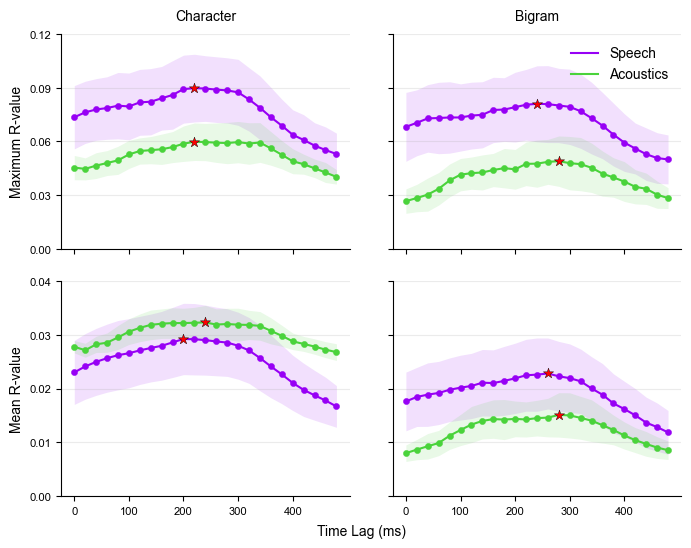

In [4]:
# -------------------------
# Display in Paper
# -------------------------
fig, [(ax_char_max, ax_word_max), (ax_char_mean, ax_word_mean)] = plt.subplots(
    2, 2, 
    figsize=(8, 6), 
    sharex=True,
    sharey="row"
)

# Maximum R
df_char, df_word = load_results(func_handle=np.max)

plot_line(ax_char_max, df_char, title="Character")
plot_line(ax_word_max, df_word, title="Bigram")

# Mean R
df_char, df_word = load_results(func_handle=np.mean)

plot_line(ax_char_mean, df_char, title=None)
plot_line(ax_word_mean, df_word, title=None)

ax_word_max.legend(frameon=False)
ax_char_max.set_ylabel("Maximum R-value")
ax_char_mean.set_ylabel("Mean R-value")
ax_word_max.tick_params(labelleft=False)
ax_word_mean.tick_params(labelleft=False)
for ax in [ax_char_max, ax_word_max]:
    ax.set_ylim(0, 0.12)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
for ax in [ax_char_mean, ax_word_mean]:
    ax.set_ylim(0, 0.04)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
fig.supxlabel("Time Lag (ms)", fontsize=10, y=0.04)
fig.subplots_adjust(wspace=0.15, hspace=0.15)

plt.show()